In [1]:
import numpy as np
import serial
import time
import matplotlib.pyplot as plt
from IPython import display
import concurrent.futures
import serial.tools.list_ports
import pandas as pd
import os
import re
ports = serial.tools.list_ports.comports()
ambit_ports = [x[0] for x in ports if "CH9102" in x[1]]
print("Available ports:", ambit_ports)
import logging
logger = logging.getLogger("serial")
logger.setLevel(logging.INFO)

Available ports: ['COM13']


In [2]:
def readline_from_port(ser: serial.Serial, init_wait: float = 0.25, line_wait: float = 0.5) -> tuple[str, bool]:
    '''
    Read a single line from the serial port. Waits for data to be available before reading. Timeout if no data is received within the specified wait times.
    Parameters:
        ser: serial.Serial
            The serial port to read from.
        init_wait: float
            The initial wait time for data to be available.
        line_wait: float
            The wait time for the rest of the line to be available.
    Returns:
        tuple[str, bool]
            str: The line read from the serial port.
            bool: True if more data is available to read, False otherwise.
    '''
    # initial wait
    _t = time.perf_counter()
    while ser.in_waiting == 0:
        if time.perf_counter() - _t > init_wait + .05:
            return "", False
        time.sleep(0.025)

    _str:str = ""
    _t = time.perf_counter()


    while True:
        if ser.in_waiting > 0:
            
            c = ser.read()
            if (c == bytes([0])) or (c > bytes([127])):
                continue           
            
            _t = time.perf_counter()
            c = c.decode('ascii')
            _str += c
            if c == '\n':
                return _str, ser.in_waiting > 0

        elif time.perf_counter() - _t > line_wait + .05:
            return _str, False
        else:
            time.sleep(0.04)

    return _str, False


def readlines_from_port(ser: serial.Serial, kw_stop = True, **argv) -> tuple[list[str], int]:
    

    line_to_line_wait = argv.get("line_wait", 2.0)
    chuck_time = argv.get("chuck_time", 999)
    chuck_size = argv.get("chuck_size", 10)
    timeout = argv.get("timeout", -1)
    ret_int = 0

    lines: list[str] = []
    _t0_start = time.perf_counter()
    kw = ["NEW Name Here Ready", "Done"]
    if timeout > 0: 
        _time_quick = _t0_start + timeout
    else:
        _time_quick = -1

    _t_start = time.perf_counter()
    _counter = 0
    while True:
        ret, more = readline_from_port(ser, init_wait=argv.get("init_wait", 0.25), line_wait=line_to_line_wait)
        if ret != "":
            lines.append(ret)
            _t_start = time.perf_counter()
            _counter += 1

        if kw_stop:
            if ret.strip() in kw:
                logger.info(f"Found stop keyword: {ret.strip()}")
                ret_int = -1
                break

        # premature stops
        if ((time.perf_counter() - _t0_start) > chuck_time) or (_counter >= chuck_size):
            ret_int = 1
            # logger.info(f"prematured chunk{time.perf_counter() - _t0_start} {_counter}")
            break

        if more:
            ret_int = 1
            continue

        # timeout
        if (time.perf_counter() - _t_start) > line_to_line_wait:
            # logger.info(f"line to line timeout{(time.perf_counter() - _t_start)}")
            ret_int = 0
            break

        if _time_quick > 0 and (time.perf_counter() > _time_quick):
            # logger.info(f"total timeout{(time.perf_counter() - _t0_start)}")
            ret_int = 0
            break
        
    return lines, ret_int


parse_data_line = re.compile(r'T:([\-\.0-9]+),F:([\.0-9]+),S:([0-9]+),R:([0-9]+),Sun:([0-9]+),L:([0-9]+)\n')
def parse_data(lines:list[str])->np.ndarray:
    _data = []
    for line in lines:
        match = parse_data_line.match(line)
        if match:
            _data.append(np.fromiter(match.groups(), dtype=float))
    return np.array(_data)

In [3]:
with serial.Serial(ambit_ports[0], 115200, timeout=1) as ser1:
    ser1.write(("hello"+'\n\r').encode())
    print(readlines_from_port(ser1, True))

(['NEW Name Here Ready\r\n'], -1)


In [12]:
with serial.Serial(ambit_ports[0], 115200) as ser1:
    ser1.write((t1.cmd_str+'\n\r').encode())
    data = []
    while True:
        lines, status = readlines_from_port(ser1, True, chunk_size = 10, line_wait=5)
        if status < 0 or len(lines) == 0: break
        data.append(parse_data(lines))
        


        print(len(data))

1


In [8]:
class Trace():
    cmd_str: str    
    run_seq: list[list[int]]
    _cmd_arr: np.ndarray



    timeline: np.ndarray
    data: np.ndarray

    

    
    def __init__(self):
        self.run_seq = []

    def add_line(self, num:int, freq:int, actinic:int = 0):
        self.run_seq.append([num, freq, actinic])

    def compile(self, persist:bool = False):
        run_seq = []
        for line in self.run_seq:
            num, freq, actinic = line
            run_seq.append([2, 0, num//256, num%256, freq//256, freq%256, actinic, 1])

        self._cmd_arr = np.reshape(run_seq, (-1, 8))
        arr_length = self._cmd_arr.shape[0]
        string = np.array2string(self._cmd_arr.flatten(), separator=',')[1:-1].replace(" ", "")
        self.cmd_str = "arrun1," + str(arr_length) + "," + str(int(persist)) + ","+ string + ",\n"

    def calc_timeline(self):
        _t, mea_tml, mea_act = 0, [], []
        for _n, _f, _a in self.run_seq:
            mea_tml.append(np.arange(_n) * _f + _t)
            mea_act.append([_a] * _n)
            _t = mea_tml[-1][-1]
        self.mea_tml = np.concatenate(mea_tml).astype(np.float32) * 0.854
        self.mea_act = np.concatenate(mea_act).astype(np.int8)


    
        
        


t1 = Trace()
t1.add_line(5, 5, 0)
t1.add_line(5, 5, 50)
t1.add_line(5, 15, 0)

t1.compile()
t1.calc_timeline()
print(t1.mea_tml)
print(t1.mea_act)

[ 0.        4.27      8.54     12.809999 17.08     17.08     21.349998
 25.619999 29.89     34.16     34.16     46.969997 59.78     72.59
 85.399994]
[ 0  0  0  0  0 50 50 50 50 50  0  0  0  0  0]


In [9]:
t1.cmd_str

'arrun1,3,0,2,0,0,5,0,5,0,1,2,0,0,5,0,5,50,1,2,0,0,5,0,15,0,1,\n'

In [ ]:
def ser_readline(ser: serial.Serial, timeout = .5, get_all_lines = False):
    t0 = time.perf_counter()
    _str = ''
    bad_counter = 0
    lines = []
    while time.perf_counter() - t0 < timeout:
        if ser.in_waiting == 0:
            time.sleep(.1)
            continue
        c = ser.read()
        if (c == bytes([0])) or (c > bytes([127])):
            bad_counter += 1
            continue

        _str += c.decode()
        if (c == b"\n") or (c == b"\r"):
            _line = _str
            if _str.startswith("Done"): return lines
            _str = ''
            if get_all_lines:
                t0 = time.perf_counter()
                lines.append(_line)
            else:
                return [_line]
        if bad_counter > 50:
            print("hex")
            break
    return lines


# def parse_data(ret1:str)->np.ndarray:
#     data = [[], [], [], [], [], []]
#     for _l in ret1:
#         if not _l.startswith("T:"): continue
#         _s = _l.split(',')
#         if len(_s) != 6: continue
#         for n in range(6):
#             _s2 = _s[n].split(':')
#             if len(_s2) != 2: continue
#             if _s2[0] == ["T", "F", "S", "R", "Sun", "L"][n]: data[n].append(float(_s2[1]))
#     return np.array(data)

#helper functions
# convert protocol to ambit array
def gen_cmd_arr_line(num:int, freq:int, actinic:int)->list:
    return [2, 0, num//256, num%256, freq//256, freq%256, actinic, 1]


# flatten ambit array, calc time, actinic array
def calc_arr_param(cmd: list, persist:bool = False):
    cmd_arr = np.reshape(cmd, (-1, 8))
    arr_length = cmd_arr.shape[0]
    cmd_str = "arrun1," + str(arr_length) + "," + str(persist) + ","+ str(cmd)[1:-1] + ",\n"
    cmd_str = cmd_str.replace(" ", "")

    num_pts = cmd_arr[:, 2] * 256 + cmd_arr[:, 3]
    act_arr = cmd_arr[:, 6]
    mea_feq = 1 / (cmd_arr[:, 4] * 256 + cmd_arr[:, 5])
    _t, mea_tml, mea_act = 0, [], []
    for _n, _f, _a in zip(num_pts, mea_feq, act_arr):
        mea_tml += (np.arange(_n) * _f + _t).tolist()
        mea_act += [_a] * _n
        _t = mea_tml[-1]
    mea_tml = np.array(mea_tml) * 0.854
    return cmd_str, mea_tml, mea_act

def run2cmd(cmd1:str, cmd2:str, ser1: serial.Serial, ser2: serial.Serial, timeout = .5, get_all_lines = False)-> tuple[str, str]:    
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
        ser1.write((cmd1+'\n\r').encode())
        ser2.write((cmd2+'\n\r').encode())
        f1 = executor.submit(ser_readline, ser1, timeout, get_all_lines)
        f2 = executor.submit(ser_readline, ser2, timeout, get_all_lines)
        result1 = f1.result()
        result2 = f2.result()
        return result1, result2
    
def run1cmd(cmd1:str, ser1: serial.Serial, timeout = .5, get_all_lines = False)-> list[str]:    
    ser1.write((cmd1+'\n\r').encode())
    result1 = ser_readline(ser1, timeout, get_all_lines)
    return result1

In [ ]:
# IF something is wrong, reboot and ask for hello again
with serial.Serial(ambit_ports[0], baudrate=115200, timeout=1) as ser1:
    r1 = run1cmd("hello", ser1, timeout=1, get_all_lines=True)
    print("Ambit 1 response:", r1)

Text(0, 0.5, 'Actinic (AU)')

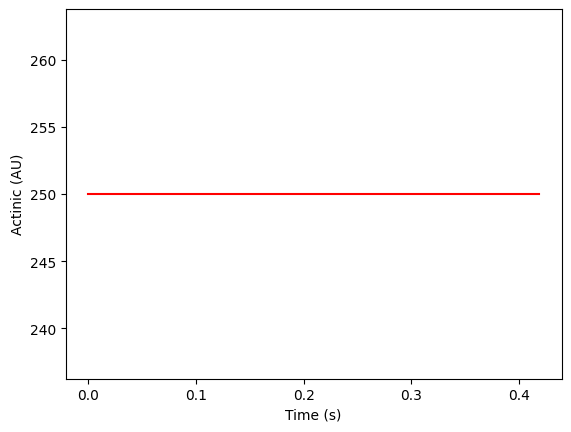

In [6]:
#----------First protocol ----------------
protocol_1 = []
# create a trace with 3 different setups:
# 1. 50 points, 10Hz, no actinic
# 2. 50 points, 50Hz, 240/255(max) actinic
# 3. 50 points, 10Hz, no actinic
# number of lines (1 - 8) points(10 - 2000), freq (1 - 200), actinic 0 - 255

cmd1 = []
# cmd1 += gen_cmd_arr_line(num = 10, freq = 5, actinic = 0)
cmd1 += gen_cmd_arr_line(num = 50, freq = 100, actinic = 250)
# cmd1 += gen_cmd_arr_line(num = 50, freq = 100, actinic = 200)
# cmd1 += gen_cmd_arr_line(num = 50, freq = 100, actinic = 100)
# cmd1 += gen_cmd_arr_line(num = 50, freq = 100, actinic = 250)
# cmd1 += gen_cmd_arr_line(num = 50, freq = 100, actinic = 0)
# cmd1 += gen_cmd_arr_line(num = 50, freq = 5, actinic = 0)
wait_time1 = 5

# convert to command for ambit, also pre-calculate the time and actinic of each point
cmd_str1, timeline1, act_arr1 = calc_arr_param(cmd1, 0)
protocol_1.append((cmd_str1, timeline1, act_arr1, wait_time1))
plt.plot(timeline1, act_arr1, 'r')



#----------Second protocol ----------------

plt.xlabel("Time (s)")
plt.ylabel("Actinic (AU)")



# cmd1 = []
# cmd1 += gen_cmd_arr_line(num = 60, freq = 1, actinic = 0)
# wait_time1 = 10

# # convert to command for ambit, also pre-calculate the time and actinic of each point
# cmd_str1, timeline1, act_arr1 = calc_arr_param(cmd1, 0)

# plt.plot(timeline1, act_arr1, 'b.')


# plt.title("Sections preview")


# protocol_1.append((cmd_str1, timeline1, act_arr1, wait_time1))


In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize = (16, 5))
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 40))  # Offset

_trace1 = ax1.plot([], [], 'c', linewidth = 1, label='Fluo')[0]
_trace2 = ax2.plot([], [], 'g', linewidth = .5, label='Temp')[0]
_trace3 = ax3.plot([], [], 'y', linewidth = .5,label='Leaf')[0]
_trace4 = ax3.plot([], [], c = 'orange', linewidth = .5, label='Sunlight')[0]

data = {"time": [], "temperature": [], "signal": [], "reflectance": [], "sunlight": []}

# Start how many cycles to run
for cycle in range(4):
    has_new_data = False
    with serial.Serial(ambit_ports[0], baudrate=115200, timeout = 10) as ser1:
        
        for (cmd_str1, timeline1, act_arr1, wt1) in protocol_1:
            has_new_data = False
            _ts = time.time()
            try:
                ret1 = run1cmd(cmd_str1, ser1, wt1, True)
            except Exception as e:
                print("Error:", e)
                continue

            try:
                ret = parse_data(ret1)
            except Exception as e:
                print("Error:", e)
                continue
            data['time'] += (_ts + timeline1).tolist()
            data['temperature'] += ret[0, :].tolist()
            _sig = ret[2, :] / ret[3, :]
            _sig[0] = np.nan
            data['signal'] += _sig.tolist()

            _sun = ret[4, :]
            _leaf = ret[5, :]
            data['reflectance'] += _leaf.tolist()
            data['sunlight'] += _sun.tolist()
            has_new_data = True

        
            if not has_new_data: continue

            _x = pd.to_datetime(data['time'], unit='s') + pd.Timedelta(9.5, unit='h')

            _trace1.set_data(_x, data['signal'])
            ax1.set_xlim(np.min(_x), np.max(_x))
            ax1.set_ylim(.95 * np.nanmin(data['signal']), 1.05 * np.nanmax(data['signal']))
            
            _trace2.set_data(_x, data['temperature'])
            ax2.set_ylim(.95 * np.nanmin(data['temperature']), 1.05 * np.nanmax(data['temperature']))

            _trace3.set_data(_x, data['reflectance'])
            _trace4.set_data(_x, data['sunlight'])
            ax3.set_ylim(.95 * np.nanmin([data['reflectance'], data['sunlight']]), 1.05 * np.nanmax([data['reflectance'], data['sunlight']]))
            
            if len(_x) > 5000:
                _trace1.set_linewidth(.25)
            
            
            plt.legend(loc='upper left')
            display.display(fig, display_id='live_plot')
            display.clear_output(wait=True)
    


    # time.sleep(20)  # wait time
df = pd.DataFrame(data)


In [ ]:
df = pd.DataFrame(data)
df.set_index('time', inplace=True)
df.index = pd.to_datetime(df.index, unit='s') + pd.Timedelta(9.5, unit='h')
df